### Telecom Churn Prediction

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
# Load the dataset

data = {
    "CustomerID": [
        1001, 1002, 1003, 1004, 1005,
        1006, 1007, 1008, 1009, 1010
    ],
    "Age": [
        22, 45, 31, 53, 26,
        39, 29, 60, 35, 42
    ],
    "MonthlyCharges": [
        350, 899, 499, 799, 299,
        650, 550, 950, 400, 720
    ],
    "TenureMonths": [
        2, 48, 12, 60, 3,
        30, 6, 72, 8, 36
    ],
    "ContractType": [
        "Month-to-Month",
        "One-Year",
        "Month-to-Month",
        "Two-Year",
        "Month-to-Month",
        "One-Year",
        "Month-to-Month",
        "Two-Year",
        "Month-to-Month",
        "One-Year"
    ],
    "InternetService": [
        "Fiber",
        "Fiber",
        "DSL",
        "Fiber",
        "DSL",
        "Fiber",
        "Fiber",
        "Fiber",
        "DSL",
        "Fiber"
    ],
    "TechSupport": [
        "No",
        "Yes",
        "No",
        "Yes",
        "No",
        "Yes",
        "No",
        "Yes",
        "No",
        "Yes"
    ],
    "StreamingTV": [
        "Yes",
        "Yes",
        "No",
        "Yes",
        "No",
        "Yes",
        "Yes",
        "Yes",
        "No",
        "Yes"
    ],
    "TotalCalls": [
        180, 420, 250, 380, 160,
        330, 270, 460, 220, 350
    ],
    "AvgCallDuration": [
        3.1, 6.2, 4.0, 5.8, 2.7,
        5.1, 3.5, 7.0, 3.8, 5.6
    ],
    "PaymentMethod": [
        "UPI",
        "Credit Card",
        "Debit Card",
        "Net Banking",
        "UPI",
        "Credit Card",
        "UPI",
        "Credit Card",
        "Debit Card",
        "Net Banking"
    ],
    "Churn": [
        1, 0, 1, 0, 1,
        0, 1, 0, 1, 0
    ]
}

df = pd.DataFrame(data)

df

,CustomerID,Age,MonthlyCharges,TenureMonths,ContractType,InternetService,TechSupport,StreamingTV,TotalCalls,AvgCallDuration,PaymentMethod,Churn
0,1001,22,350,2,Month-to-Month,Fiber,No,Yes,180,3.1,UPI,1
1,1002,45,899,48,One-Year,Fiber,Yes,Yes,420,6.2,Credit Card,0
2,1003,31,499,12,Month-to-Month,DSL,No,No,250,4.0,Debit Card,1
3,1004,53,799,60,Two-Year,Fiber,Yes,Yes,380,5.8,Net Banking,0
4,1005,26,299,3,Month-to-Month,DSL,No,No,160,2.7,UPI,1
5,1006,39,650,30,One-Year,Fiber,Yes,Yes,330,5.1,Credit Card,0
6,1007,29,550,6,Month-to-Month,Fiber,No,Yes,270,3.5,UPI,1
7,1008,60,950,72,Two-Year,Fiber,Yes,Yes,460,7.0,Credit Card,0
8,1009,35,400,8,Month-to-Month,DSL,No,No,220,3.8,Debit Card,1
9,1010,42,720,36,One-Year,Fiber,Yes,Yes,350,5.6,Net Banking,0


In [3]:
# We will remove the columns that are not necessary in training the model

new_df = df.drop(columns=['CustomerID', 'ContractType', 'InternetService', 'TechSupport', 'StreamingTV', 'TotalCalls', 'AvgCallDuration', 'PaymentMethod'])
new_df

,Age,MonthlyCharges,TenureMonths,Churn
0,22,350,2,1
1,45,899,48,0
2,31,499,12,1
3,53,799,60,0
4,26,299,3,1
5,39,650,30,0
6,29,550,6,1
7,60,950,72,0
8,35,400,8,1
9,42,720,36,0


In [4]:
# Convert the dataframe in numpy array
X = new_df[['Age','MonthlyCharges','TenureMonths']].to_numpy()
y = new_df['Churn'].to_numpy()

In [5]:
# Normalize the features
mean = X.mean(axis=0)
std = X.std(axis=0)

X_scaled = (X-mean)/std

In [6]:
# Initialize before training

m,n = X_scaled.shape  # m -> number of samples, n -> number of features
weights = np.zeros(n)
bias = 0

learning_rate = 0.1
epochs = 3000

In [7]:
# Sigmoid function

def sigmoid(z):
    return 1/(1+np.exp(-z))

In [8]:
# Logistic Regression Algorithm

for epoch in range(epochs):
    # Forward pass
    z = np.dot(X_scaled,weights) + bias
    prediction = sigmoid(z)

    # Gradients
    dw = (1/m) * np.dot(X_scaled.T, (prediction-y))
    db = (1/m) * np.sum(prediction-y)

    # Update
    weights -= learning_rate*dw
    bias -= learning_rate*db

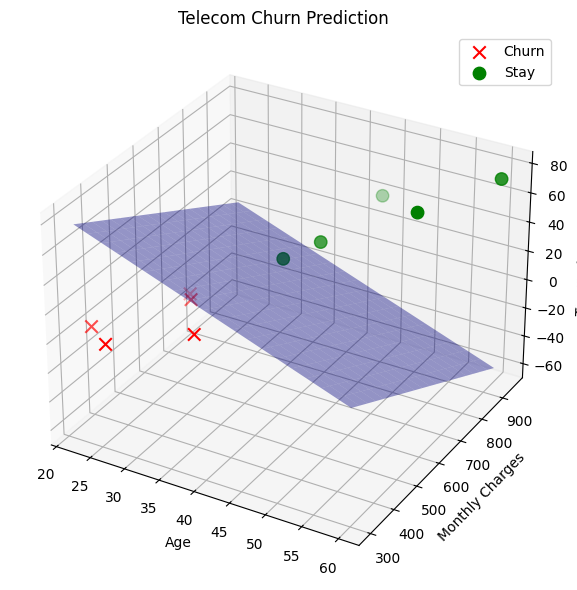

In [21]:
# ============================================================
# 3D PLOT
# ============================================================

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

# Customers who churned
ax.scatter(
    X[y==1,0],
    X[y==1,1],
    X[y==1,2],
    color='red',
    marker='x',
    s=80,
    label='Churn',
    depthshade=True
)

# Customers who stayed
ax.scatter(
    X[y==0,0],
    X[y==0,1],
    X[y==0,2],
    color='green',
    marker='o',
    s=80,
    label='Stay',
    depthshade=True
)

# ============================================================
# DECISION PLANE
# ============================================================

age = np.linspace(
    X[:,0].min(),
    X[:,0].max(),
    20
)

monthly = np.linspace(
    X[:,1].min(),
    X[:,1].max(),
    20
)

Age, Monthly = np.meshgrid(age, monthly)

Age_scaled = (Age - mean[0]) / std[0]
Monthly_scaled = (Monthly - mean[1]) / std[1]

Tenure_scaled = -(
    weights[0] * Age_scaled
    +
    weights[1] * Monthly_scaled
    +
    bias
) / weights[2]

Tenure = (
    Tenure_scaled * std[2]
) + mean[2]


ax.plot_surface(
    Age,
    Monthly,
    Tenure,
    alpha=0.4,
    color='blue'
)

# ============================================================
# LABELS
# ============================================================

ax.set_xlabel("Age")
ax.set_ylabel("Monthly Charges")
ax.set_zlabel("Tenure (Months)")
ax.set_title("Telecom Churn Prediction")

ax.legend()
plt.tight_layout()

plt.show()

##### **Observation** : *From the above graph we can observe that the customers below the age of **30** are more likely to leave the subscription of telecom because they have shorter term plans. While on the other hand, people above the age of **40** are less likely to leave because they have longer term plans.*